# Load Libraries

In [85]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model selection / preprocessing
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Set seed

In [2]:
seed = 42
np.random.seed(seed)

# Load Dataset

In [3]:
raw_df = pd.read_csv("online_shoppers_intention.csv")

display(raw_df.head())
display(raw_df.shape)
raw_df.columns

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


(12330, 18)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

### Load Data

#### Dataset structure
- 12,330 rows and 18 columns.
- Each row is a single online shopping session.
- `Revenue` is the target variable.

#### Feature types
- Mixture of:
    - continuous variables
    - count variables
    - binary variables
    - coded categorical variables

#### Session framing
- This is a session level classification task.
- We are looking for browsing behavior associated with purchase outcomes.

#### Pre-processing implications
- Numeric and categorical variables will need separate handling later.
    - `Month`, `VisitorType`, `Weekend` are categorical.
- Some numeric-coded predictors may be better treated as categorical.
  - `SpecialDay`, `Browser`, `OperatingSystems`, `TrafficType`, and `Region` are numeric-coded categories

### We would like to look into 
1. Target Balance
2. Correlation heatmap
3. Behavioral differences with the target
4. Distribution shapes and zero inflation (transformations if needed)
5. Numerical variables distributions
6. Categorical variables 
7. Month based differences for seasonal trends (as well as special days)

> Source: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

---

# EDA

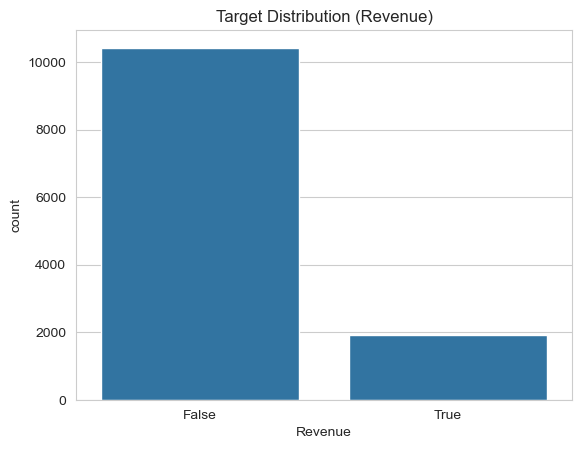

,Percentage,Count
Revenue,,
False,84.525547,10422
True,15.474453,1908


In [4]:
# Target Distribution
sns.countplot(x='Revenue', data=raw_df)
plt.title("Target Distribution (Revenue)")
plt.show()

# table
raw_target_distribution_table = pd.DataFrame({
    'Percentage': raw_df['Revenue'].value_counts(normalize=True) * 100,
    'Count': raw_df['Revenue'].value_counts()
})

raw_target_distribution_table

### Revenue Distribution:
- Class balance
    - 10,422 (84.5%) vs 1,908 (15.5%)
- Metric choice
    - Accuracy could mislead due to imbalance. Model predicting mostly "False" could appear 'good'.
    - Other metrics like precision, recall, F1, ROC-AUC, PR AUC would suffice
##### Pre-processing decisions
- Stratified train/validate/test split to keep proportions similar across splits.

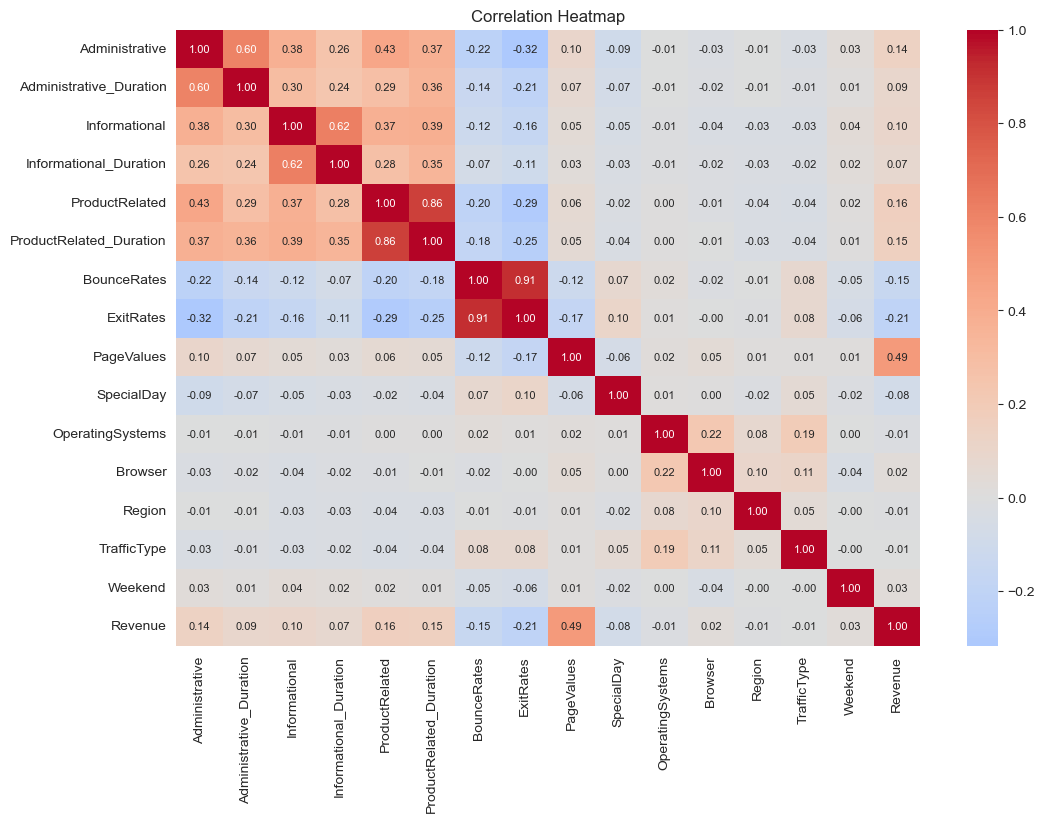

,Revenue
Revenue,1.000
PageValues,0.493
ProductRelated,0.159
ProductRelated_Duration,0.152
Administrative,0.139
Informational,0.095
Administrative_Duration,0.094
Informational_Duration,0.070
Weekend,0.029
Browser,0.024


In [5]:
# correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    raw_df.corr(numeric_only=True), 
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Correlation Heatmap")
plt.show()

# correlation with target
raw_target_correlations_table = raw_df.corr(numeric_only=True)
pd.DataFrame(raw_target_correlations_table['Revenue']
             .sort_values(ascending=False)
             .round(3)
            )

### Correlation heatmap
- Strongest linear signal to `Revenue`
  - `PageValues` has the strongest positive linear relationship with `Revenue`.
  - `ExitRates` and `BounceRates` show the clearest negative relationships.

- Predictor overlap
  - Page-count and duration pairs are closely related.
  - `BounceRates` and `ExitRates` also appear to carry overlapping information.

##### Pre-processing decisions
- Watch for multicollinearity in linear models.
- For tree-based models, this overlap is less concerning.
- Coded numeric variables should still be treated as categorical rather than interpreted through correlation strength.

In [6]:
# Missing / zero summary table
n = len(raw_df)

# Create masks
na_mask = raw_df.isna()
empty_mask = raw_df.eq("")
zero_mask = raw_df.select_dtypes(include=np.number).eq(0)

# Create summary table
summary_table = pd.DataFrame(index=raw_df.columns)

summary_table["NA Count"] = na_mask.sum()
summary_table["NA %"] = na_mask.mean() * 100

summary_table["Empty String Count"] = empty_mask.sum()
summary_table["Empty String %"] = empty_mask.mean() * 100

summary_table["Zero Count"] = zero_mask.sum().reindex(raw_df.columns, fill_value=0)
summary_table["Zero %"] = (zero_mask.mean() * 100).reindex(raw_df.columns, fill_value=0)

# display 
display(summary_table.round(2))

,NA Count,NA %,Empty String Count,Empty String %,Zero Count,Zero %
Administrative,0,0.0,0,0.0,5768,46.78
Administrative_Duration,0,0.0,0,0.0,5903,47.88
Informational,0,0.0,0,0.0,9699,78.66
Informational_Duration,0,0.0,0,0.0,9925,80.49
ProductRelated,0,0.0,0,0.0,38,0.31
ProductRelated_Duration,0,0.0,0,0.0,755,6.12
BounceRates,0,0.0,0,0.0,5518,44.75
ExitRates,0,0.0,0,0.0,76,0.62
PageValues,0,0.0,0,0.0,9600,77.86
SpecialDay,0,0.0,0,0.0,11079,89.85


### Missingness
- NAs & empties
    - No features contain NAs or empty values, this was expected as noted from source, but checked anyway for best practice.

- Zero inflation
    - `Administrative`, `Administrative_Duration`, `Informational`, and `Informational_Duration` contain many zeros, suggesting that a large share of sessions did not involve those types of pages at all.
    - `PageValues` is also heavily zero-inflated, which is expected since many sessions likely did not progress far enough to generate purchase related data.
    - `SpecialDay` being nearly 90% zero is reasonable, since most browsing sessions would not occur near a holiday or special shopping-related date like black friday.
    - In contrast, `ProductRelated` and `ProductRelated_Duration` contain very few zeros, indicating that most sessions involved product-page interaction.

##### Take away
- The dataset does not deal with missingess, however we can see a trend with sparse behavior among most predictors

## Numeric Variable Analysis

In [7]:
# We don't want to look at numeric categorical features in EDA, they'll be preprocessed later
num_cat_cols = ['SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType'] # numeric categorical features

num_cols = [
    col for col in raw_df.select_dtypes(include=np.number).columns
    if col not in num_cat_cols
]

In [8]:
# Skewness
raw_num_skewness = raw_df[num_cols].skew()

# raw skewness table
raw_num_skewness_table = pd.DataFrame(raw_num_skewness, columns=["Skewness"]).sort_values(by="Skewness", ascending=False)
raw_num_skewness_table

,Skewness
Informational_Duration,7.579185
ProductRelated_Duration,7.263228
PageValues,6.382964
Administrative_Duration,5.615719
ProductRelated,4.341516
Informational,4.036464
BounceRates,2.947855
ExitRates,2.148789
Administrative,1.960357


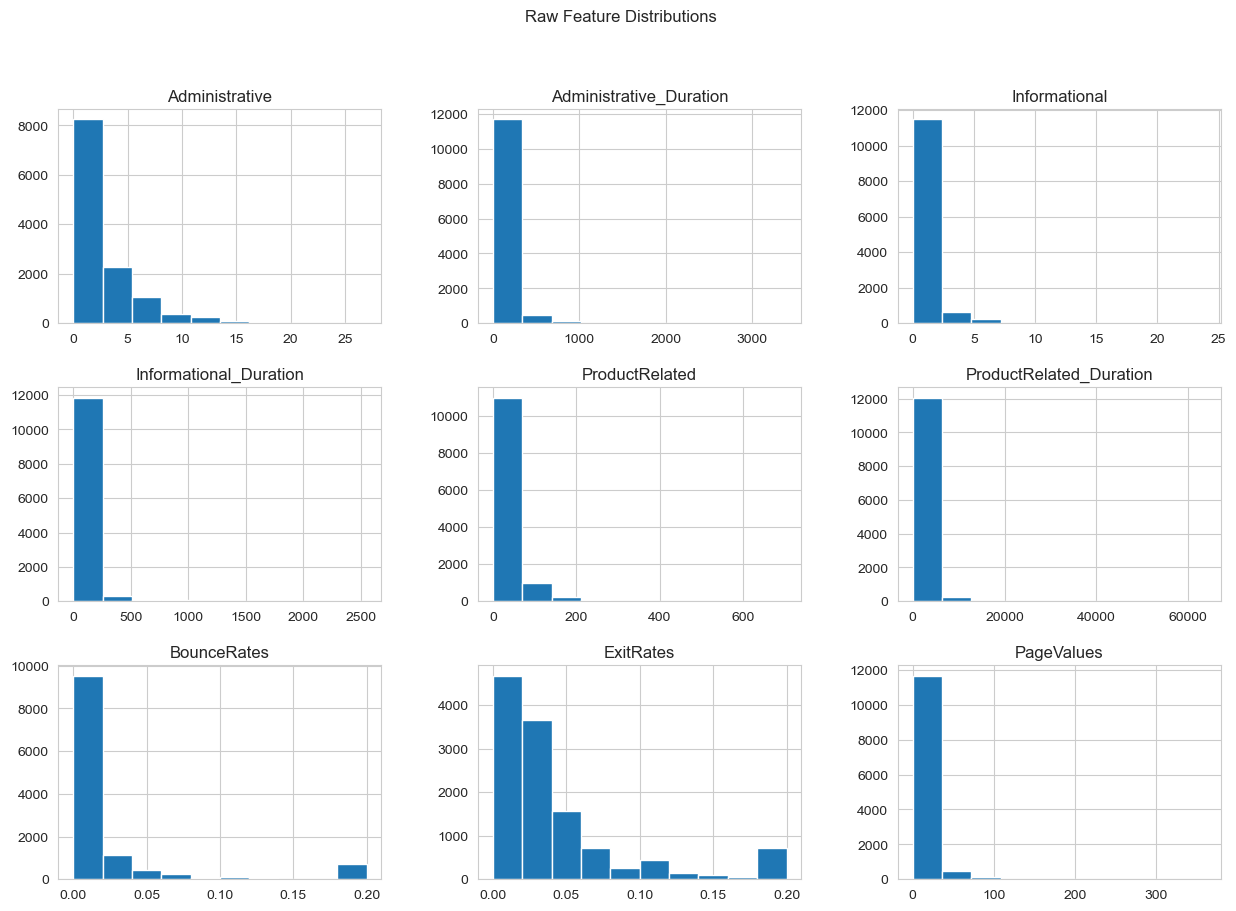

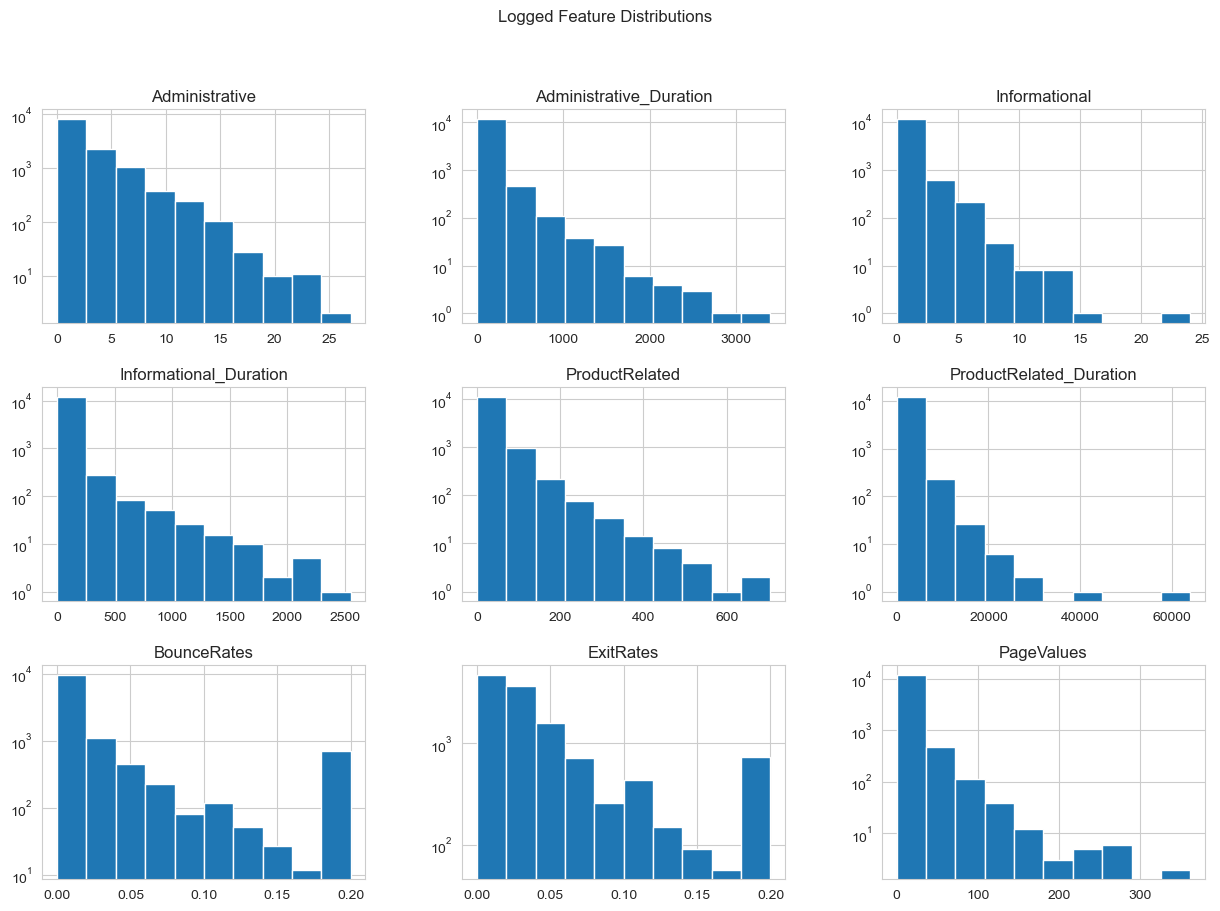

In [9]:
# Feature Distributions
raw_df[num_cols].hist(figsize=(15,10))
plt.suptitle("Raw Feature Distributions")
plt.show()

# logged distribution check
raw_df[num_cols].hist(figsize=(15,10), log=True)
plt.suptitle("Logged Feature Distributions")
plt.show()

### Raw vs log-transformed distributions
- Raw vs transformed shape
  - The raw duration variables and `PageValues` are heavily compressed near 0 with long right tails.
  - After `log1p()`, the non-zero portion becomes much easier to inspect.

- Transformation insight
  - `ProductRelated_Duration` improves the most after transformation.
  - `Administrative_Duration`, `Informational_Duration`, and `PageValues` still retain a large spike at 0.

- Zero inflation
  - `SpecialDay`, `Informational`, `Informational_Duration`, and `PageValues` are heavily skewed.

#### Pre-processing decisions:
- `log1p()` is a reasonable option for these variables.
- Zeros should be kept as valid values.
- A separate binary indicator for any activity may be worth testing later for variables with many zeros.

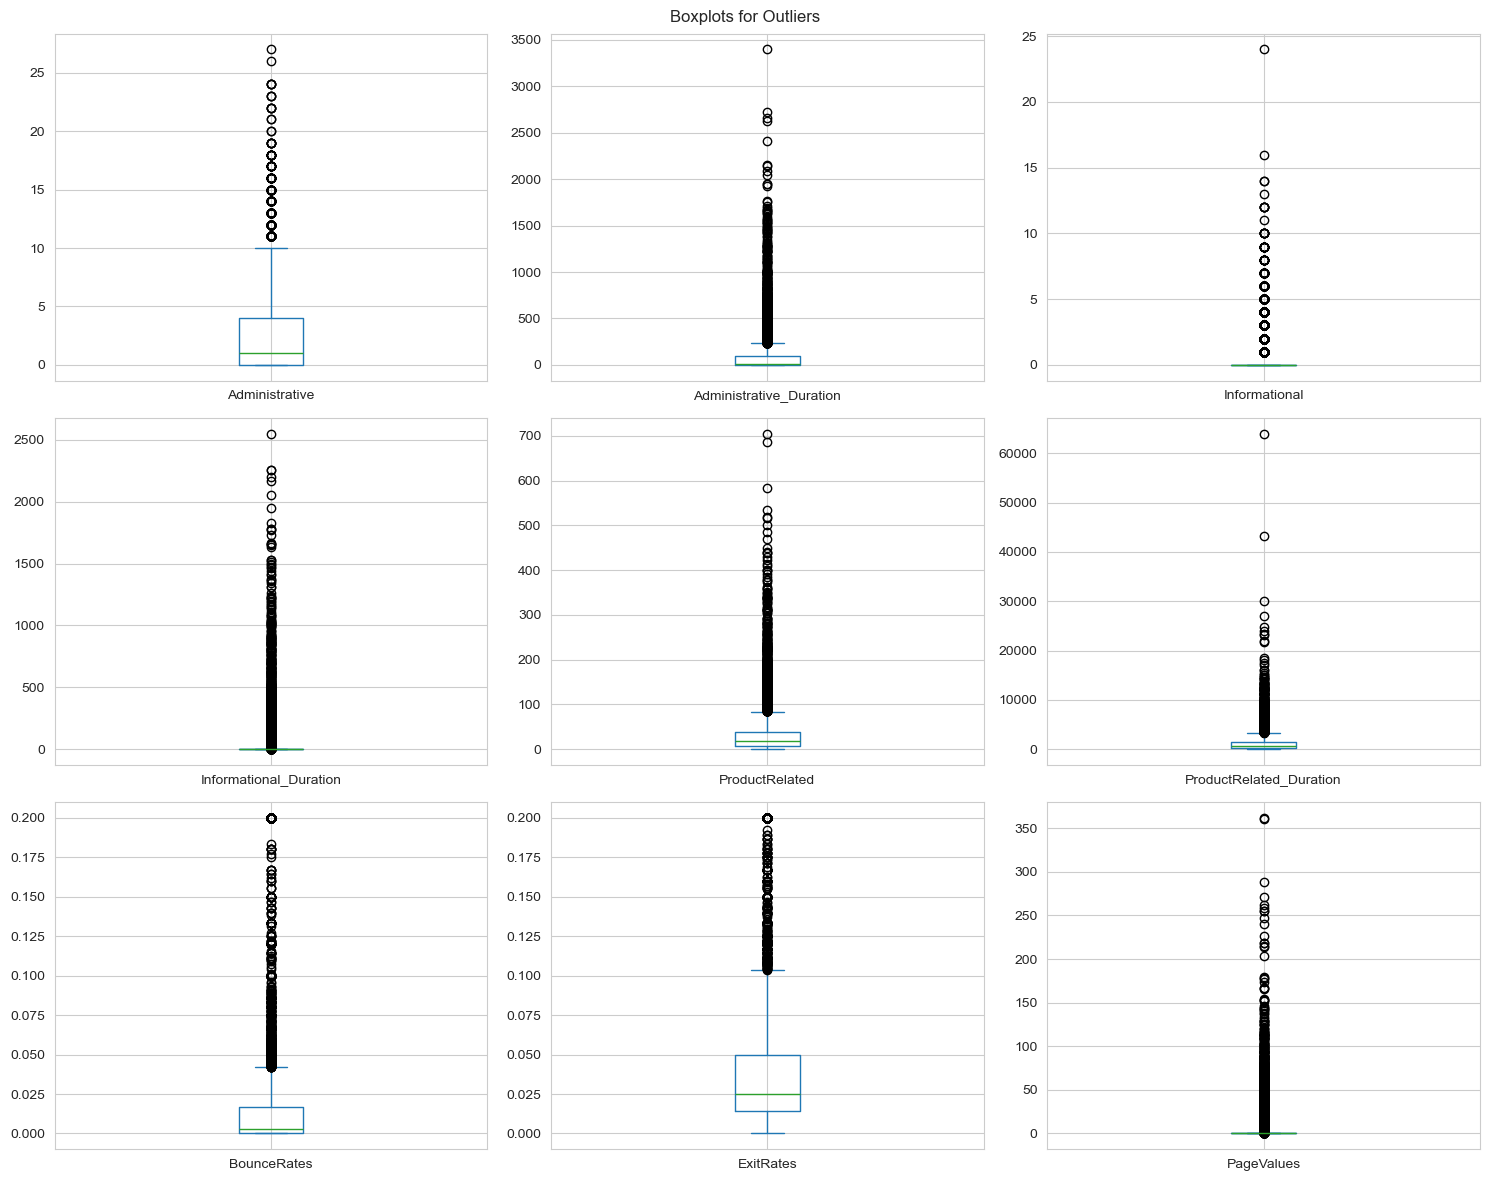

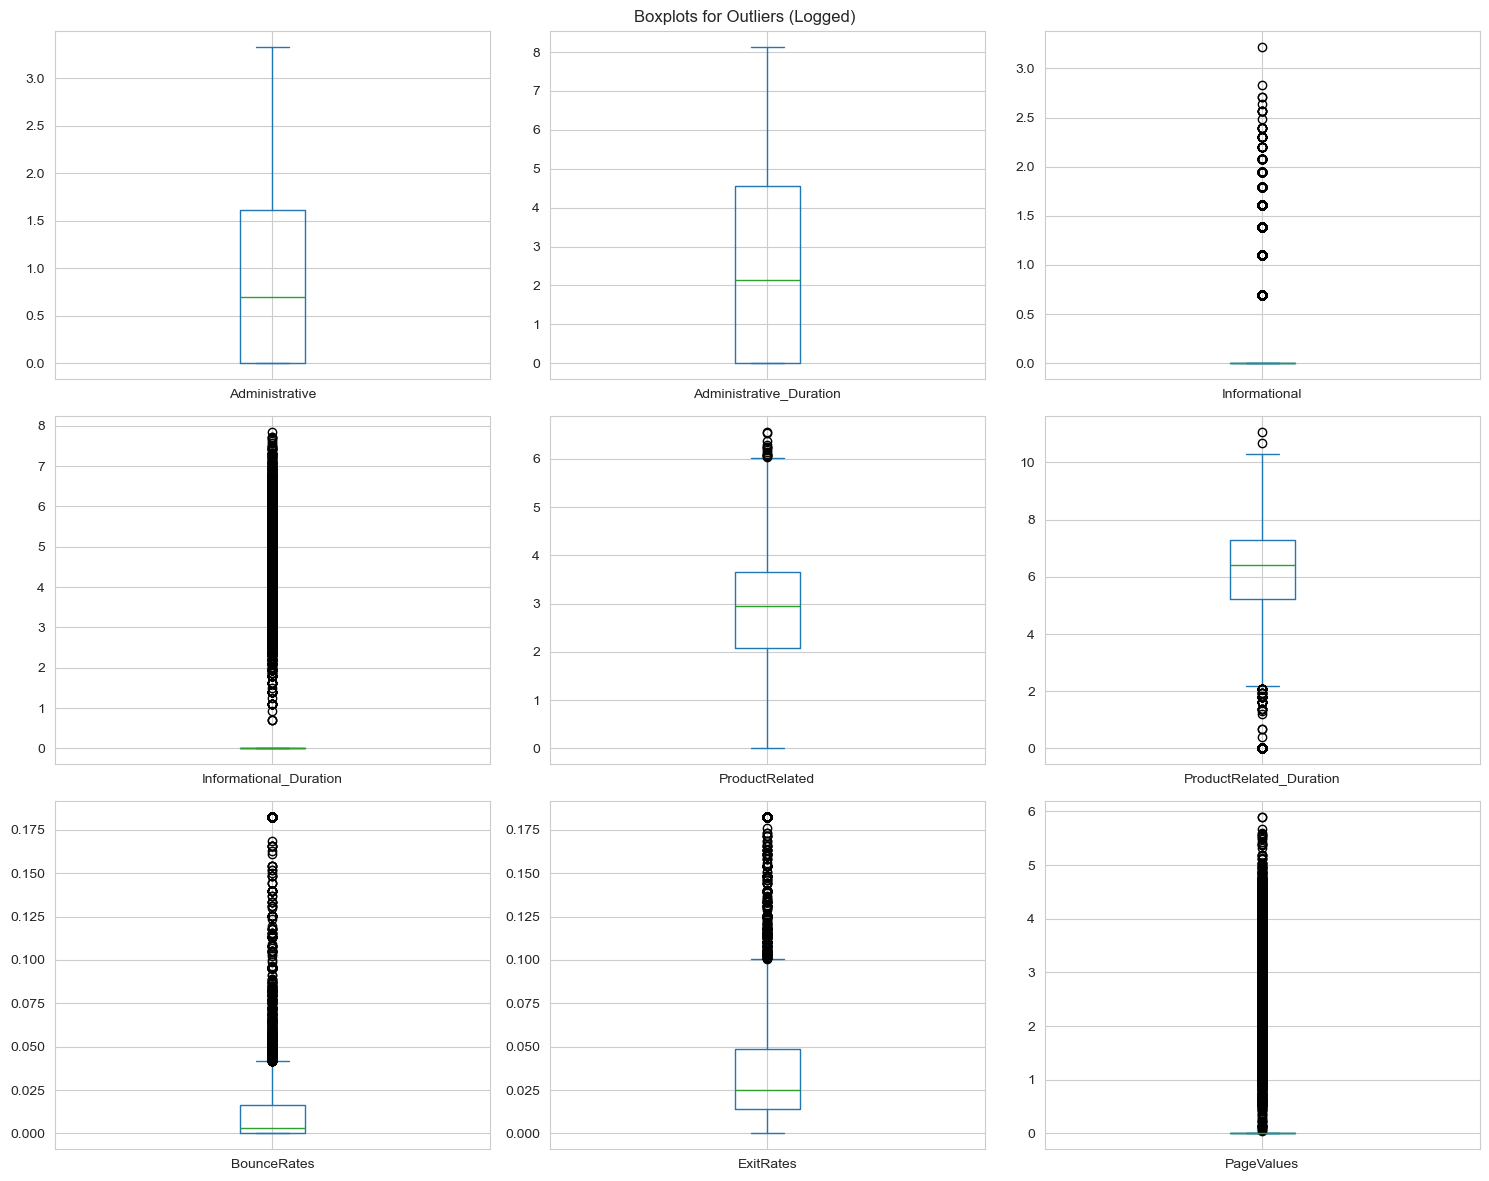

In [10]:
# Boxplots for outliers
raw_df[num_cols].plot(
    kind='box',
    subplots=True,
    layout=(-1, 3),
    figsize=(15, 12),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots for Outliers")
plt.tight_layout()
plt.show()

# Boxplots for outliers (logged)
np.log1p(raw_df[num_cols]).plot(
    kind='box',
    subplots=True,
    layout=(-1, 3),
    figsize=(15, 12),
    sharex=False,
    sharey=False
)

plt.suptitle("Boxplots for Outliers (Logged)")
plt.tight_layout()
plt.show()

### Boxplots
- Outliers
    - Most boxplots are heavily influenced by zero inflation, which compresses much of the data near 0.
    - `Administrative` and `Administrative_Duration`, as well as `ProductRelated` and `ProductRelated_Duration`, become easier to inspect after log transformation.

- Take away
    - Apparent outliers are partly a result of strong right skew and many zero values.
    - This further supports testing both raw and log-transformed versions in modeling.

## Categorical Variable Analysis

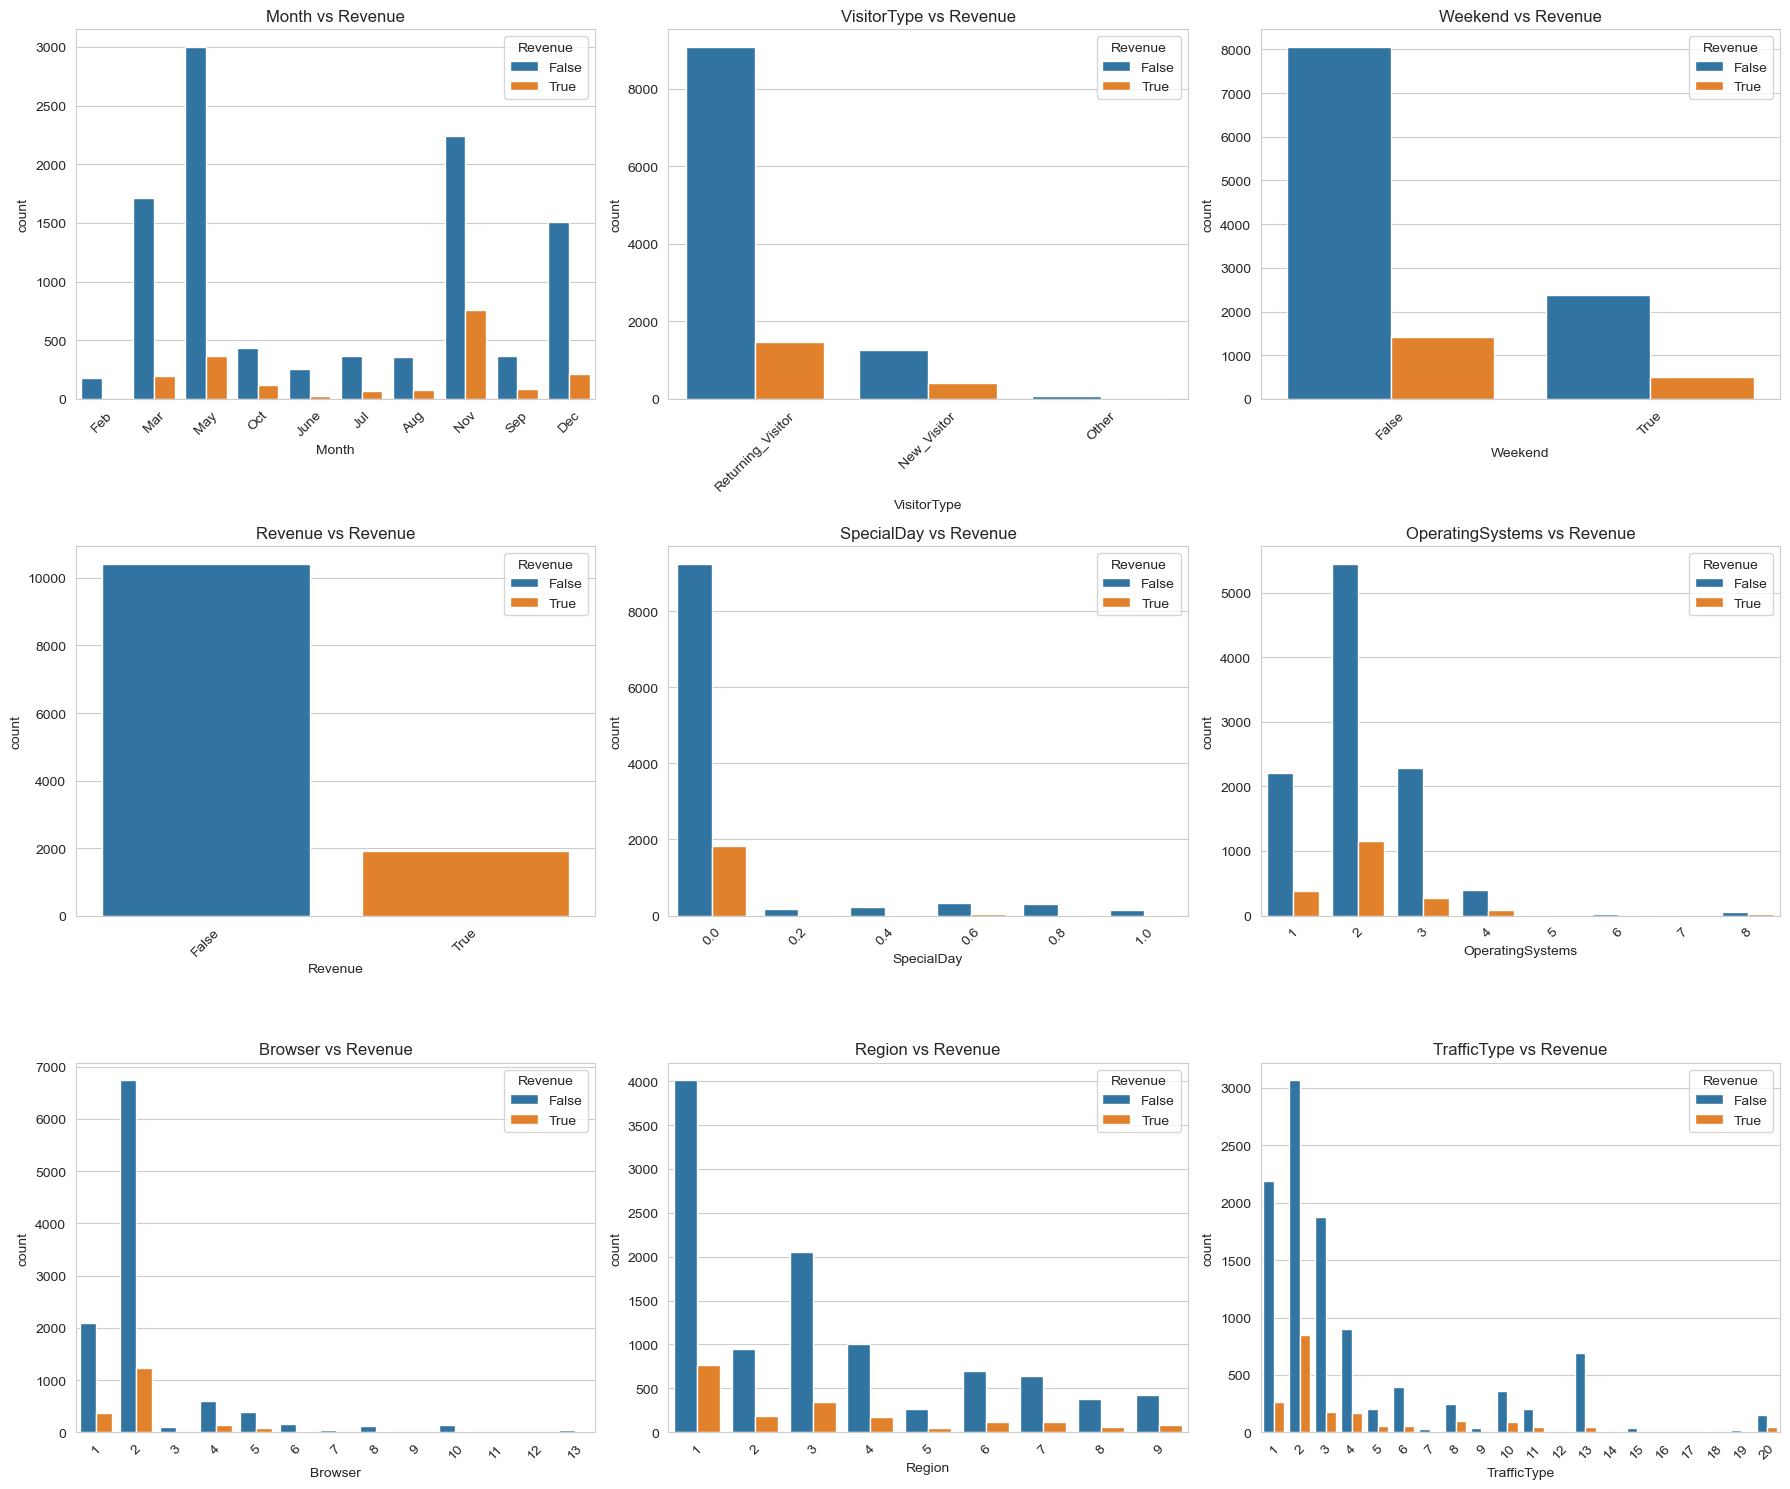


Month purchase rate:
Month
Nov     0.253502
Oct     0.209472
Sep     0.191964
Aug     0.175520
Jul     0.152778
Dec     0.125072
May     0.108502
June    0.100694
Mar     0.100682
Feb     0.016304
Name: Revenue, dtype: float64

VisitorType purchase rate:
VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

Weekend purchase rate:
Weekend
True     0.173989
False    0.148911
Name: Revenue, dtype: float64

Revenue purchase rate:
Revenue
True     1.0
False    0.0
Name: Revenue, dtype: float64

SpecialDay purchase rate:
SpecialDay
0.0    0.165268
0.6    0.082621
0.2    0.078652
1.0    0.064935
0.4    0.053498
0.8    0.033846
Name: Revenue, dtype: float64

OperatingSystems purchase rate:
OperatingSystems
8    0.215190
4    0.177824
2    0.174973
5    0.166667
1    0.146615
7    0.142857
6    0.105263
3    0.104892
Name: Revenue, dtype: float64

Browser purchase rate:
Browser
12    0.300000
13    0.262295
10    0.

In [11]:
# Identify categorical columns
cat_cols = raw_df.select_dtypes(include=['object', 'bool']).columns.tolist() + num_cat_cols

# Set subplot grid shape
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

# Create subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Count plots for each categorical feature vs Revenue
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=raw_df, x=col, hue='Revenue', ax=ax)
    ax.set_title(f"{col} vs Revenue")
    ax.tick_params(axis='x', rotation=45)

# Remove any unused subplot axes
for ax in axes[len(cat_cols):]:
    fig.delaxes(ax)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

# Purchase rate by category
for col in cat_cols:
    print(f"\n{col} purchase rate:")
    print(raw_df.groupby(col)['Revenue'].mean().sort_values(ascending=False))

### Categoricals

- Behavioral trends
    - `Month` shows some seasonal differences, with stronger purchase rates in months like November and October. But contradictory with March and May.
    - `VisitorType` suggests New_Visitor sessions purchase at a higher rate than Returning_Visitor sessions.
    - `Weekend` shows only a small difference.

- Numerical encoded predictors
    - `SpecialDay` acts more like a closeness metric than a standard numeric variable.
    - `OperatingSystems`, `Browser`, `Region`, and `TrafficType` are coded categories, but are not strongly interpretable on their own.

- Take away
    - `Month`, `VisitorType`, and `Weekend` are the most interpretable categorical predictors.
    - The numeric-coded categorical variables may still help prediction, but add little behavioral insight without further documentation.

---

# Pre-processing

In [12]:
# Convert target to binary
df = raw_df.copy()
df['Revenue'] = df['Revenue'].astype(int)

# List of variables lacking documentation
drop_cols = ['SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

# drop columns from df
df.drop(columns=drop_cols, inplace=True)

# check columns after dropping
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'Month', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [13]:
# Separate Features and Target
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

# Identify Feature Types
categorical_cols = ["Month", "VisitorType", "Weekend"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing Pipelines
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [14]:
# Train/Validation/Test Splits ; 85 / 15 ; using CV inside train

# Final holdout test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=seed
)

print("Train full:", X_train_full.shape)
print("Test:", X_test.shape)

Train full: (10480, 12)
Test: (1850, 12)


In [15]:
# folds for GridSearchCV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

---

# **Baseline Models**

## Baseline Model 1: Decision Tree
- This gives a rule-based model to compare against the tuned ensemble methods

In [ ]:
dt_baseline_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        random_state=seed
    ))
])

In [ ]:
# Each observation is predicted by a model that did not train on that observation.
dt_baseline_cv_pred = cross_val_predict(
    estimator=dt_baseline_pipe,
    X=X_train_full,
    y=y_train_full,
    cv=cv,
    method="predict",
    n_jobs=-1
)

In [ ]:
# Standard classification summary
print(classification_report(y_train_full, dt_baseline_cv_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      8858
           1       0.71      0.59      0.64      1622

    accuracy                           0.90     10480
   macro avg       0.82      0.77      0.79     10480
weighted avg       0.89      0.90      0.90     10480



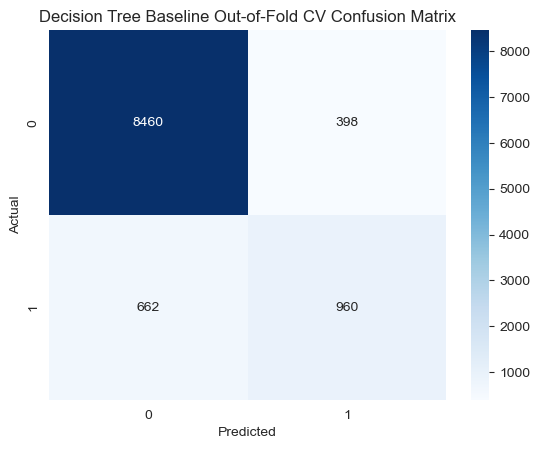

In [ ]:
# Out-of-fold confusion matrix
dt_baseline_cv_cm = confusion_matrix(y_train_full, dt_baseline_cv_pred)

sns.heatmap(dt_baseline_cv_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Baseline Out-of-Fold CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Decision Tree Baseline
- Metrics
    - CV F1: `0.64`, better than logistic regression for the purchase class
    - Precision: `0.71`, purchase predictions are fairly reliable
    - Recall: `0.59`, more purchasers are found than with the logistic baseline, but sensitivity is still moderate
    - ROC-AUC: `0.92`, the tree separates purchase and non-purchase sessions reasonably well
    - Average Precision: `0.69`, minority-class ranking is decent, but not among the strongest models
- Take away
    - The tree supports the idea that purchase behavior contains nonlinear decision structure
    - It improves interpretability through simple rule-based splits, but serves best as a baseline rather than a final model choice

## Baseline Model 2: Logistic Regression
- Simple interpretable linear baseline.
- Useful for checking whether more complex nonlinear models add real value.

In [ ]:
log_baseline_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=seed
    ))
])

In [ ]:
# Standard classification summary
log_baseline_cv_pred = cross_val_predict(
    estimator=log_baseline_pipe,
    X=X_train_full,
    y=y_train_full,
    cv=cv,
    method="predict",
    n_jobs=-1
)

print(classification_report(y_train_full, log_baseline_cv_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.93      8858
           1       0.74      0.38      0.50      1622

    accuracy                           0.88     10480
   macro avg       0.82      0.68      0.72     10480
weighted avg       0.87      0.88      0.87     10480



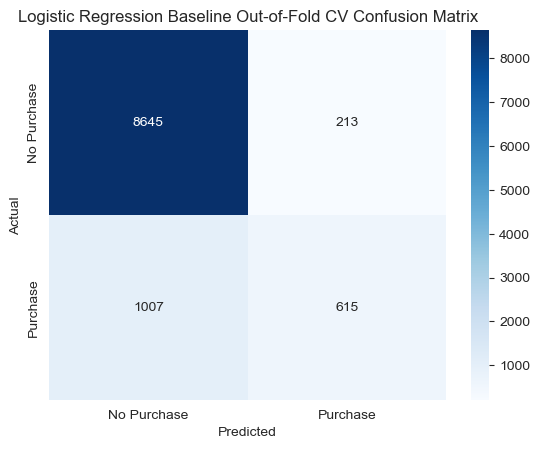

In [ ]:
# Out-of-fold confusion matrix
log_baseline_cv_cm = confusion_matrix(y_train_full, log_baseline_cv_pred)

sns.heatmap(
    log_baseline_cv_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)
plt.title("Logistic Regression Baseline Out-of-Fold CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Logistic Regression Baseline

- Metrics
    - CV F1: `0.50`, weaker than the tree-based models for purchase detection
    - Precision: `0.74`, predicted purchases are fairly reliable
    - Recall: `0.38`, the model misses many true purchase sessions
    - ROC-AUC: `0.90`, class separation is still reasonably strong
    - Average Precision: `0.65`, the minority class contains usable signal, but the baseline remains limited

- Take away
    - Logistic regression serves as a useful interpretable baseline
    - The weaker recall supports the idea that purchase behavior is not fully captured by a simple linear decision boundary

Main Metric:
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---

# **Models**
- Random Forest
- Gradient Boosting
- XGBoost
- SVM ; non-tree based

## **Random Forest:**

### RF setup

In [21]:
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=seed))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 10, 15, None],
    "classifier__min_samples_split": [2, 10, 20],
    "classifier__min_samples_leaf": [1, 5, 10],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"]
}

### RF grid search tuning

In [22]:
rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train_full, y_train_full)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


### RF best tune

In [23]:
rf_best_model = rf_search.best_estimator_
rf_best_params = rf_search.best_params_
rf_best_cv_f1 = rf_search.best_score_

print("Best RF Params:")
print(rf_best_params)

print(f"\nBest RF CV F1: {rf_best_cv_f1:.4f}")

Best RF Params:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}

Best RF CV F1: 0.6876


### RF out-of-fold (oof) CV predictions

In [24]:
rf_cv_pred = cross_val_predict(
    estimator=rf_best_model,
    X=X_train_full,
    y=y_train_full,
    cv=cv,
    method="predict",
    n_jobs=-1
)

rf_cv_prob = cross_val_predict(
    estimator=rf_best_model,
    X=X_train_full,
    y=y_train_full,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

### RF oof cm

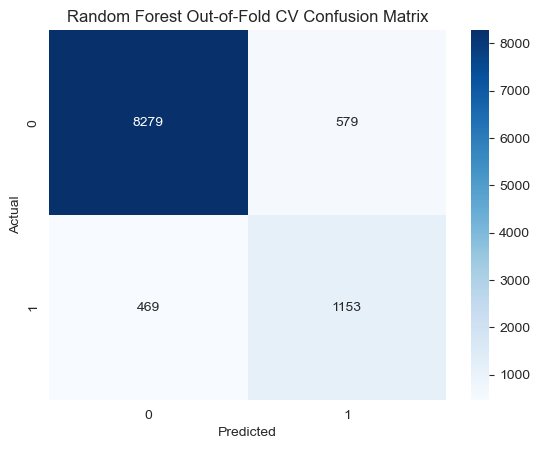

In [25]:
rf_cv_cm = confusion_matrix(y_train_full, rf_cv_pred)

sns.heatmap(rf_cv_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Out-of-Fold CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### RF oof roc

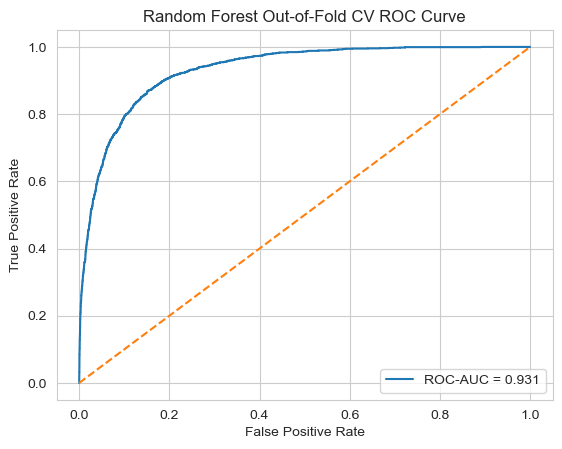

In [26]:
rf_cv_fpr, rf_cv_tpr, _ = roc_curve(y_train_full, rf_cv_prob)
rf_cv_auc = roc_auc_score(y_train_full, rf_cv_prob)

plt.plot(rf_cv_fpr, rf_cv_tpr, label=f"ROC-AUC = {rf_cv_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest Out-of-Fold CV ROC Curve")
plt.legend()
plt.show()

### RF oof precision-recall

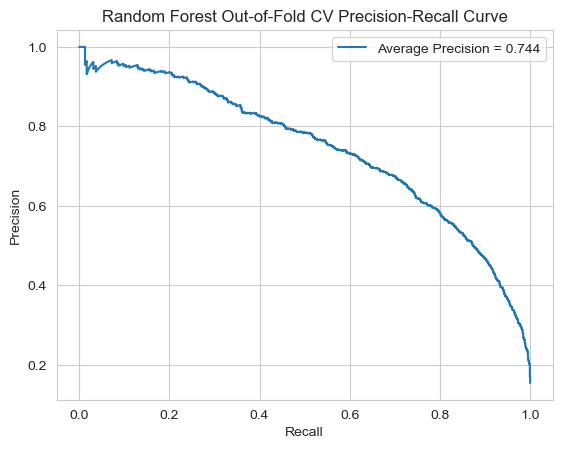

In [27]:
rf_cv_precision, rf_cv_recall, _ = precision_recall_curve(y_train_full, rf_cv_prob)
rf_cv_ap = average_precision_score(y_train_full, rf_cv_prob)

plt.plot(rf_cv_recall, rf_cv_precision, label=f"Average Precision = {rf_cv_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Out-of-Fold CV Precision-Recall Curve")
plt.legend()
plt.show()

### Random Forest (Needs updating)
- Metrics
    - F1 class 0: 0.94, the model continues to classify non-purchase sessions very well
    - F1 class 1: 0.60, a small improvement over the decision tree for purchase sessions
    - ROC-AUC: 0.916, stronger class separation than the earlier models
    - The forest improves performance by combining many trees, reducing the instability of a single tree while capturing more complex structure

- Take away
    - The gain over the decision tree is modest, but it suggests added complexity is helping
    - Purchase behavior likely contains nonlinear patterns that are better captured through an ensemble rather than one fixed tree

## **Gradient Boosting:**

### GB setup

In [28]:
gb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=seed))
])

gb_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
    "classifier__subsample": [0.8, 1.0],
    "classifier__min_samples_split": [2, 10, 20],
    "classifier__min_samples_leaf": [1, 5, 10]
}

### GB search tuning

In [29]:
gb_search = GridSearchCV(
    estimator=gb_pipe,
    param_grid=gb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gb_search.fit(X_train_full, y_train_full)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__min_samples_leaf': [1, 5, ...], 'classifier__min_samples_split': [2, 10, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


### GB best tune

In [30]:
gb_best_model = gb_search.best_estimator_
gb_best_params = gb_search.best_params_
gb_best_cv_f1 = gb_search.best_score_

print("Best GB Params:")
print(gb_best_params)

print(f"\nBest GB CV F1: {gb_best_cv_f1:.4f}")

Best GB Params:
{'classifier__learning_rate': 0.03, 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 20, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}

Best GB CV F1: 0.6666


### GB Out-of-fold CV predictions

In [31]:
gb_cv_pred = cross_val_predict(
    estimator=gb_best_model,
    X=X_train_full,
    y=y_train_full,
    cv=cv,
    method="predict",
    n_jobs=-1
)

gb_cv_prob = cross_val_predict(
    estimator=gb_best_model,
    X=X_train_full,
    y=y_train_full,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

### GB Out-of-fold CV confusion matrix

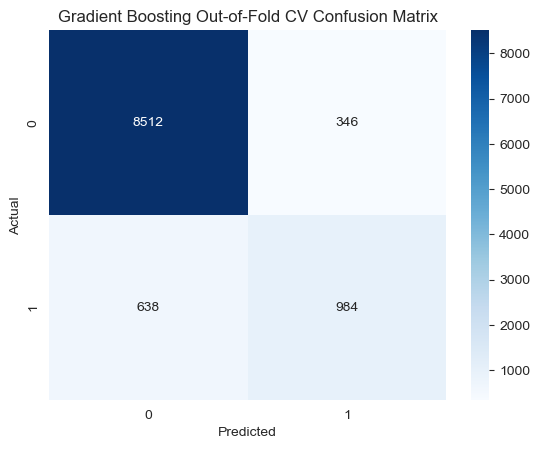

In [ ]:
gb_cv_cm = confusion_matrix(y_train_full, gb_cv_pred)

sns.heatmap(gb_cv_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Gradient Boosting Out-of-Fold CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### GB Out-of-fold CV ROC curve

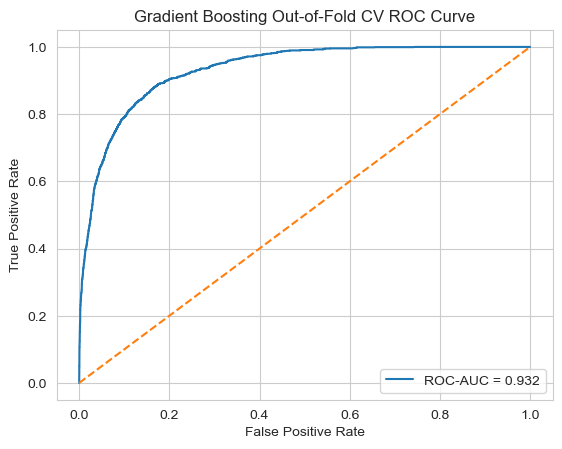

In [33]:
gb_cv_fpr, gb_cv_tpr, _ = roc_curve(y_train_full, gb_cv_prob)
gb_cv_auc = roc_auc_score(y_train_full, gb_cv_prob)

plt.plot(gb_cv_fpr, gb_cv_tpr, label=f"ROC-AUC = {gb_cv_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting Out-of-Fold CV ROC Curve")
plt.legend()
plt.show()

### GB Out-of-fold CV precision-recall curve

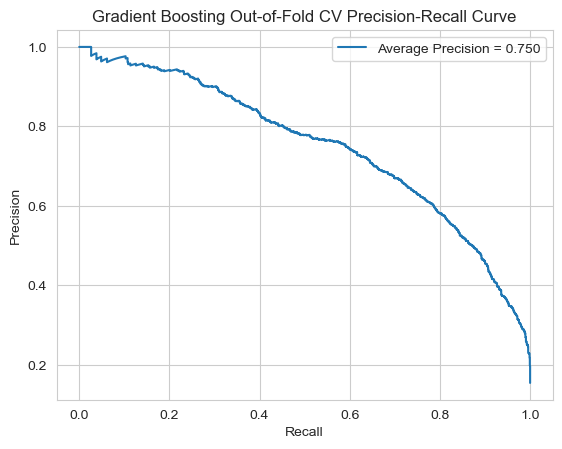

In [34]:
gb_cv_precision, gb_cv_recall, _ = precision_recall_curve(y_train_full, gb_cv_prob)
gb_cv_ap = average_precision_score(y_train_full, gb_cv_prob)

plt.plot(gb_cv_recall, gb_cv_precision, label=f"Average Precision = {gb_cv_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Gradient Boosting Out-of-Fold CV Precision-Recall Curve")
plt.legend()
plt.show()

### Gradient Boosting (Needs Updating)
- Metrics
    - F1 class 0: 0.94, the model continues to classify non-purchase sessions very well
    - F1 class 1: 0.62, the strongest performance so far for purchase sessions
    - ROC-AUC: 0.920, slightly better class separation than the random forest
    - Boosting improves by sequentially focusing on mistakes made by earlier trees, which likely helps capture harder purchase-session patterns

- Take away
    - The improvement in class 1 performance suggests boosting is better at learning the minority-class structure
    - This supports the idea that purchase behavior contains more complex patterns than a single tree or simple linear boundary can capture

## **XGBoost:**

### XGB setup

In [42]:
xgb_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=seed
    ))
])

### XGB hyperparameter grid

In [ ]:
xgb_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [3, 4, 5],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__reg_alpha": [0, 0.1, 1],
    "classifier__reg_lambda": [1, 5, 10],
    "classifier__scale_pos_weight": [1, 2, 3, 5]
}

### XGB grid search

In [44]:
xgb_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

xgb_search.fit(X_train_full, y_train_full)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


### XGB best tune

In [45]:
xgb_best_model = xgb_search.best_estimator_
xgb_best_params = xgb_search.best_params_
xgb_best_cv_f1 = xgb_search.best_score_

print("Best XGB Params:")
print(xgb_best_params)

print(f"\nBest XGB CV F1: {xgb_best_cv_f1:.4f}")

Best XGB Params:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 100, 'classifier__reg_alpha': 0.1, 'classifier__reg_lambda': 5, 'classifier__scale_pos_weight': 2, 'classifier__subsample': 1.0}

Best XGB CV F1: 0.6950


### XGB CV predictions

In [46]:
xgb_cv_pred = cross_val_predict(
    estimator=xgb_best_model,
    X=X_train_full,
    y=y_train_full,
    cv=cv,
    method="predict",
    n_jobs=-1
)

print(classification_report(y_train_full, xgb_cv_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      8858
           1       0.67      0.73      0.69      1622

    accuracy                           0.90     10480
   macro avg       0.81      0.83      0.82     10480
weighted avg       0.91      0.90      0.90     10480



### XGB confusion matrix

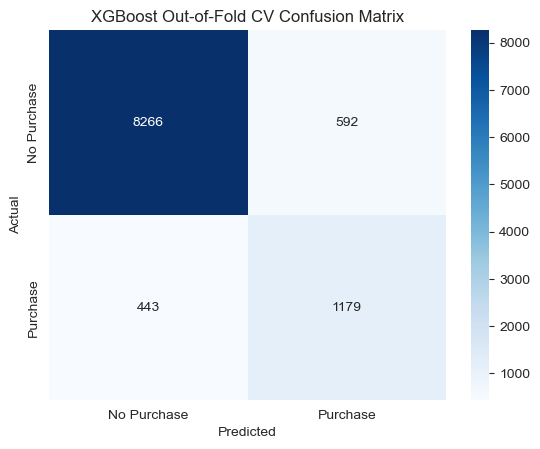

In [47]:
xgb_cv_cm = confusion_matrix(y_train_full, xgb_cv_pred)

sns.heatmap(
    xgb_cv_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)
plt.title("XGBoost Out-of-Fold CV Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **Suppport Vector Machine:**

### setup

In [35]:
svm_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC())
])

svm_param_grid = {
    "classifier__C": [0.1, 1, 10],
    "classifier__kernel": ["rbf"],
    "classifier__gamma": ["scale", 0.01, 0.1],
    "classifier__class_weight": [None, "balanced"]
}

### Grid search tuning

In [36]:
svm_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

svm_search.fit(X_train_full, y_train_full)

,estimator,"Pipeline(step...ier', SVC())])"
,param_grid,"{'classifier__C': [0.1, 1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__gamma': ['scale', 0.01, ...], 'classifier__kernel': ['rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


### Best tuned SVM

In [37]:
svm_best_model = svm_search.best_estimator_
svm_best_params = svm_search.best_params_
svm_best_cv_f1 = svm_search.best_score_

print("Best SVM Params:")
print(svm_best_params)

print(f"\nBest SVM CV ROC-AUC: {svm_best_cv_f1:.4f}")

Best SVM Params:
{'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}

Best SVM CV ROC-AUC: 0.6586


### Support Vector Machine (Needs Updating)
- Metrics
    - F1 class 0: 0.94, the model still identifies non-purchase sessions well
    - F1 class 1: 0.58, weaker than the random forest and gradient boosting for purchase sessions
    - ROC-AUC: 0.856, lower class separation than the earlier models
    - The SVM performs reasonably, but does not appear to capture the purchase-session structure as effectively as the tree-based ensembles

- Take away
    - This suggests the nonlinear boundary used by SVM is not as well matched to this dataset as the ensemble tree methods
    - More complexity does not automatically mean better performance

---

## **Comparison:**

In [ ]:
model_dict = {
    "Logistic Regression Baseline": log_baseline_pipe,
    "Decision Tree Baseline": dt_baseline_pipe,
    "Random Forest": rf_best_model,
    "Gradient Boosting": gb_best_model,
    "SVM": svm_best_model,
    "XGBoost": xgb_best_model
}

model_results = []

for model_name, model_obj in model_dict.items():
    cv_results = cross_validate(
        estimator=model_obj,
        X=X_train_full,
        y=y_train_full,
        cv=cv,
        scoring={
            "f1": "f1",
            "precision": "precision",
            "recall": "recall",
            "roc_auc": "roc_auc",
            "average_precision": "average_precision"
        },
        n_jobs=-1,
        return_train_score=False
    )
    
    model_results.append({
        "model": model_name,
        "cv_f1": cv_results["test_f1"].mean(),
        "cv_precision": cv_results["test_precision"].mean(),
        "cv_recall": cv_results["test_recall"].mean(),
        "cv_roc_auc": cv_results["test_roc_auc"].mean(),
        "cv_average_precision": cv_results["test_average_precision"].mean()
    })

In [58]:
model_compare = (
    pd.DataFrame(model_results)
    .sort_values("cv_f1", ascending=False)
    .reset_index(drop=True)
)

display(model_compare)

,model,cv_f1,cv_precision,cv_recall,cv_roc_auc,cv_average_precision
0,XGBoost,0.695030,0.665912,0.726887,0.932863,0.751539
1,Random Forest,0.687593,0.666004,0.710847,0.931618,0.744715
2,Gradient Boosting,0.666558,0.739864,0.606657,0.933123,0.751630
3,SVM,0.658618,0.574186,0.772488,0.909347,0.688050
4,Decision Tree Baseline,0.644205,0.707788,0.591863,0.918130,0.688760
5,Logistic Regression Baseline,0.500484,0.741126,0.379155,0.896470,0.645382


### Interpretation
- XGBoost has the best CV F1 at 0.695, with strong recall and solid precision.
- Random Forest is very close at 0.688, also balanced.
- Gradient Boosting has the best or near-best ROC-AUC / AP, but its recall is noticeably lower, which is why its F1 trails XGBoost and RF.
- SVM is recall-heavy but precision-weak.
- Logistic is precise but misses too many purchasers.

---

# **Threshold Tuning**

### models

In [ ]:
model_tuning = model_compare.head(6)["model"].tolist()
model_tuning

['XGBoost',
 'Random Forest',
 'Gradient Boosting',
 'SVM',
 'Decision Tree Baseline',
 'Logistic Regression Baseline']

### Model lookup (will use later too)

In [ ]:
# One shared lookup for model comparison, threshold tuning, and final test selection
best_model_lookup = {
    "Logistic Regression Baseline": log_baseline_pipe,
    "Decision Tree Baseline": dt_baseline_pipe,
    "Random Forest": rf_best_model,
    "Gradient Boosting": gb_best_model,
    "SVM": svm_best_model,
    "XGBoost": xgb_best_model
}

### Threshold tuning on OOF predictions
- start at 0.10
- end at 0.90
- test every 0.01

In [ ]:
threshold_grid = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for model_name in model_tuning:
    model_obj = best_model_lookup[model_name]
    
    if hasattr(model_obj, "predict_proba"):
        oof_score = cross_val_predict(
            estimator=model_obj,
            X=X_train_full,
            y=y_train_full,
            cv=cv,
            method="predict_proba",
            n_jobs=-1
        )[:, 1]
    else:
        oof_score = cross_val_predict(
            estimator=model_obj,
            X=X_train_full,
            y=y_train_full,
            cv=cv,
            method="decision_function",
            n_jobs=-1
        )
    
    best_threshold = None
    best_f1 = -1
    best_precision = None
    best_recall = None
    
    for threshold in threshold_grid:
        oof_pred = (oof_score >= threshold).astype(int)
        current_f1 = f1_score(y_train_full, oof_pred)
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold
            best_precision = precision_score(y_train_full, oof_pred, zero_division=0)
            best_recall = recall_score(y_train_full, oof_pred, zero_division=0)
    
    threshold_results.append({
        "model": model_name,
        "best_threshold": best_threshold,
        "oof_f1": best_f1,
        "oof_precision": best_precision,
        "oof_recall": best_recall,
        "oof_roc_auc": roc_auc_score(y_train_full, oof_score),
        "oof_average_precision": average_precision_score(y_train_full, oof_score)
    })

In [75]:
threshold_compare = (
    pd.DataFrame(threshold_results)
    .sort_values("oof_f1", ascending=False)
    .reset_index(drop=True)
)

display(threshold_compare)

,model,best_threshold,oof_f1,oof_precision,oof_recall,oof_roc_auc,oof_average_precision
0,XGBoost,0.50,0.694960,0.665726,0.726880,0.932480,0.750526
1,Random Forest,0.49,0.687793,0.656215,0.722565,0.931486,0.744299
2,Gradient Boosting,0.36,0.687388,0.667053,0.709001,0.932284,0.750074
3,Decision Tree Baseline,0.33,0.684987,0.645232,0.729963,0.918448,0.694369
4,SVM,0.38,0.667621,0.623196,0.718866,0.909248,0.686234
5,Logistic Regression Baseline,0.26,0.632401,0.669421,0.599260,0.896257,0.644337


---

# Final Evaluation on Test Set

### Final Model Selection

In [78]:
chosen_model_name = threshold_compare.loc[0, "model"]
chosen_threshold = threshold_compare.loc[0, "best_threshold"]

print("Chosen model:", chosen_model_name)
print("Chosen threshold:", chosen_threshold)

final_model = best_model_lookup[chosen_model_name]

Chosen model: XGBoost
Chosen threshold: 0.4999999999999998


### Final Test Predictions

In [79]:
if hasattr(final_model, "predict_proba"):
    final_test_score = final_model.predict_proba(X_test)[:, 1]
else:
    final_test_score = final_model.decision_function(X_test)

final_test_pred = (final_test_score >= chosen_threshold).astype(int)

### Final Test Classification Report

In [80]:
print(classification_report(y_test, final_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1564
           1       0.66      0.73      0.69       286

    accuracy                           0.90      1850
   macro avg       0.80      0.83      0.82      1850
weighted avg       0.90      0.90      0.90      1850



### Final Test Confusion Matrix

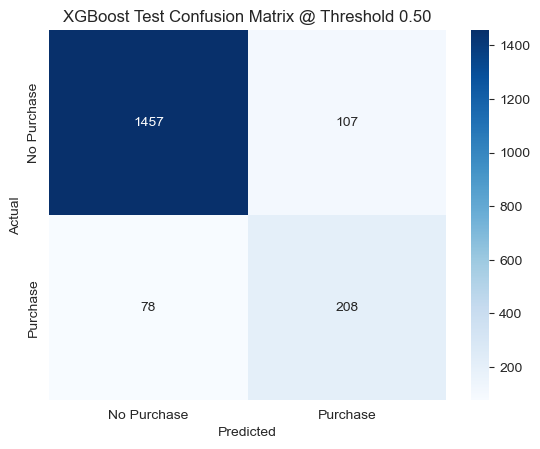

In [81]:
final_test_cm = confusion_matrix(y_test, final_test_pred)

sns.heatmap(
    final_test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)
plt.title(f"{chosen_model_name} Test Confusion Matrix @ Threshold {chosen_threshold:.2f}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Final Test ROC Curve

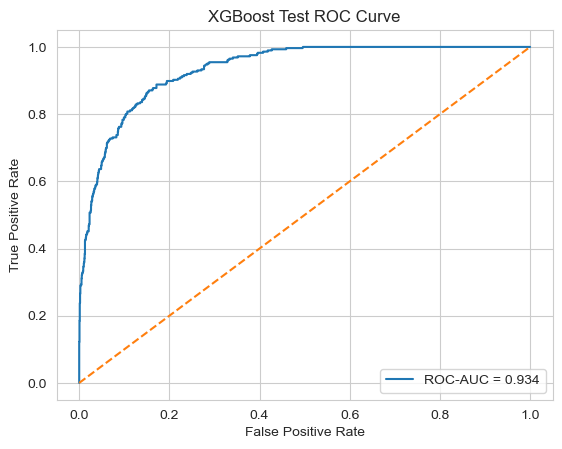

In [83]:
final_test_auc = roc_auc_score(y_test, final_test_score)

final_test_fpr, final_test_tpr, _ = roc_curve(y_test, final_test_score)

plt.plot(final_test_fpr, final_test_tpr, label=f"ROC-AUC = {final_test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{chosen_model_name} Test ROC Curve")
plt.legend()
plt.show()

### Final Test Precision-Recall Curve

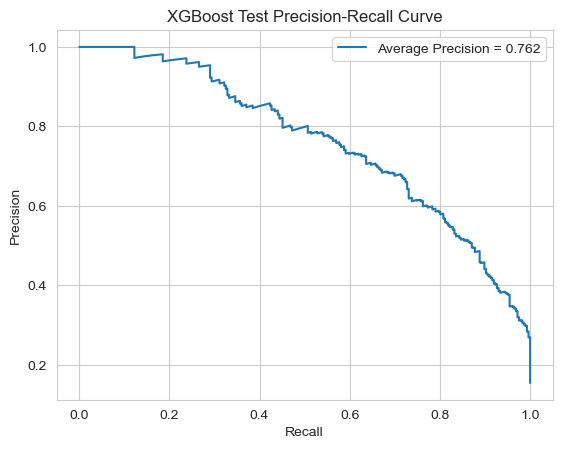

In [84]:
final_test_ap = average_precision_score(y_test, final_test_score)

final_test_precision_curve, final_test_recall_curve, _ = precision_recall_curve(
    y_test,
    final_test_score
)

plt.plot(
    final_test_recall_curve,
    final_test_precision_curve,
    label=f"Average Precision = {final_test_ap:.3f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{chosen_model_name} Test Precision-Recall Curve")
plt.legend()
plt.show()

---

### Future Directions

- Additional models
    - LightGBM, or CatBoost could be tested as other strong boosting methods.
    - A standard neural network could be attempted for improvement.

- Model tuning
    - Hyperparameter tuning may improve the current random forest more than switching immediately to entirely new model family.
    - Threshold tuning is worth testing since the default cutoff may not be optimal for class 1 F1 or recall.
    - Class weighting or imbalance-focused tuning could help improve purchase-session sensitivity.

- Feature transformations
    - Log transformation is still worth testing for strongly right-skewed variables, especially the duration variables and PageValues.
    - This may help linear-type models more than tree-based models, but is still a reasonable comparison to make.
    - With zero-inflation, we could switch features to binary for activity vs no-activity.

- Feature reduction
    - Some variables may be redundant, especially the page-count and duration pairs, as well as BounceRates and ExitRates.
    - Reduction methods could test whether a smaller feature set keeps similar performance while improving interpretability.
    - This can be done through correlation review, model-based importance, or regularization-based selection.

#### Take away
- The most useful next steps are likely tuning, threshold adjustment, log transformation tests, and feature reduction.